# Carregando dados e imports

In [1]:
from collections import Counter
from datetime import datetime
import json

import pandas as pd
import matplotlib.pyplot as plt


with open('../data/raw/survey_responses.json', 'r', encoding="utf-8") as f:
    data = json.load(f)

print(f"Quantidade de respostas: {len(data)}")

Quantidade de respostas: 22


# Analisando perguntas de informações pessoais e profissionais

## Gênero e categoria de trabalho

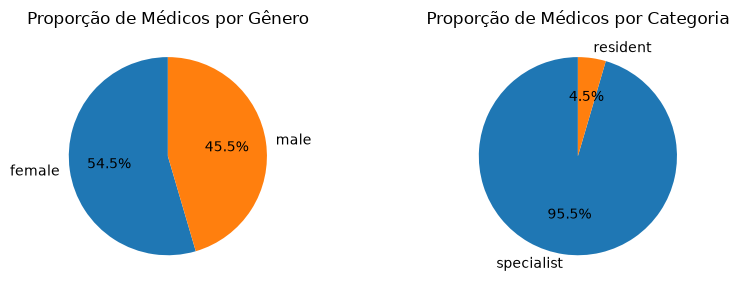

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

gender_counts = Counter(user['gender'] for user in data)
gender_percentages = {k: (v / len(data)) * 100 for k, v in gender_counts.items()}

axes[0].pie(
    gender_percentages.values(),
    labels=gender_percentages.keys(),
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Proporção de Médicos por Gênero')

category_counts = Counter(user['category'] for user in data)
category_percentages = {k: (v / len(data)) * 100 for k, v in category_counts.items()}

axes[1].pie(
    category_percentages.values(),
    labels=category_percentages.keys(),
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporção de Médicos por Categoria')

plt.tight_layout()
plt.show()

## Local de trabalho e Especialidade médica

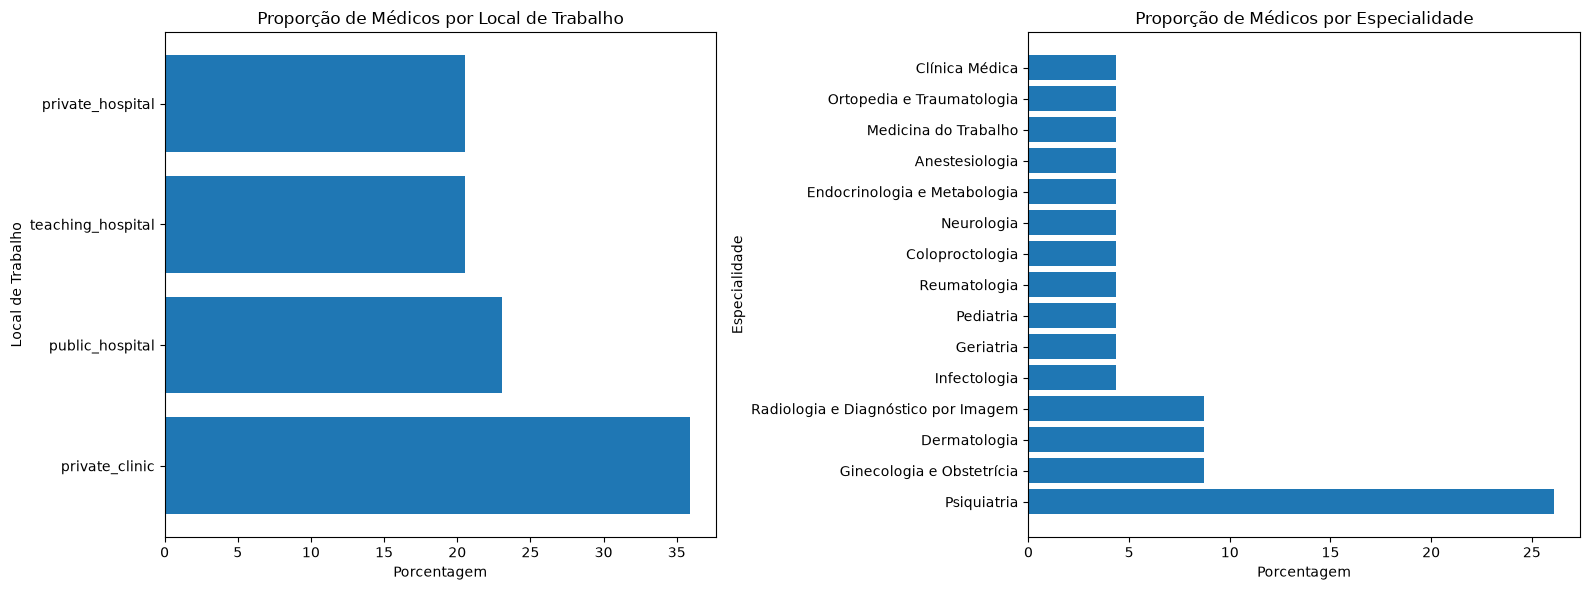

In [3]:
workplace_counts = Counter(workplace for user in data for workplace in user['workplaces'])
workplace_df = pd.DataFrame.from_dict(workplace_counts, orient='index', columns=['count'])
workplace_df['percentage'] = (workplace_df['count'] / workplace_df['count'].sum()) * 100
workplace_df.sort_values('percentage', ascending=False, inplace=True)

specialty_counts = Counter(specialty for user in data for specialty in user['specialties'])
specialty_df = pd.DataFrame.from_dict(specialty_counts, orient='index', columns=['count'])
specialty_df['percentage'] = (specialty_df['count'] / specialty_df['count'].sum()) * 100
specialty_df.sort_values('percentage', ascending=False, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(workplace_df.index, workplace_df['percentage'])
axes[0].set_title('Proporção de Médicos por Local de Trabalho')
axes[0].set_xlabel('Porcentagem')
axes[0].set_ylabel('Local de Trabalho')

axes[1].barh(specialty_df.index, specialty_df['percentage'])
axes[1].set_title('Proporção de Médicos por Especialidade')
axes[1].set_xlabel('Porcentagem')
axes[1].set_ylabel('Especialidade')

plt.tight_layout()
plt.show()

## Idade e Tempo de Experiência Profissional

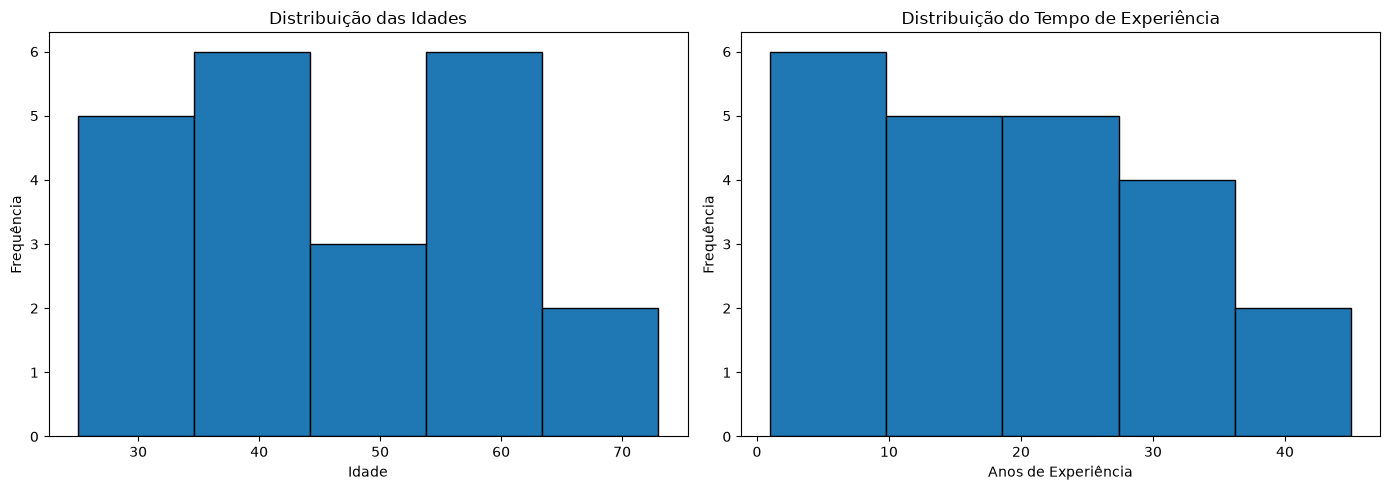

In [4]:
current_year = datetime.now().year
ages = [current_year - datetime.strptime(user['birthDate'], '%Y-%m-%d').year for user in data]
experience_years = [user['yearsOfPractice'] for user in data]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ages, bins=5, edgecolor='black')
axes[0].set_title('Distribuição das Idades')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')

axes[1].hist(experience_years, bins=5, edgecolor='black')
axes[1].set_title('Distribuição do Tempo de Experiência')
axes[1].set_xlabel('Anos de Experiência')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

In [5]:
def descriptive_stats(values):
    s = pd.Series(values, dtype="float")
    modes = s.mode().tolist()
    return {
        "n": int(s.count()),
        "média": s.mean(),
        "mediana": s.median(),
        "desvio_padrão": s.std(ddof=1),
        "mín": s.min(),
        "máx": s.max(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "moda": modes[0] if modes else None,
    }

current_year = datetime.now().year
ages = [current_year - datetime.strptime(user['birthDate'], '%Y-%m-%d').year for user in data]
experience_years = [user['yearsOfPractice'] for user in data]

stats = {
    "Idade": descriptive_stats(ages),
    "Experiência": descriptive_stats(experience_years)
}

stats_df = pd.DataFrame(stats).T

print("Análise estatística das idades e anos de experiência:")
print(stats_df.round(2))

Análise estatística das idades e anos de experiência:
                n  média  mediana  desvio_padrão   mín   máx    iqr  moda
Idade        22.0  46.23     45.5          12.64  25.0  73.0  18.75  39.0
Experiência  22.0  18.68     17.5          13.18   1.0  45.0  20.50   3.0


# Perguntas de conhecimento prévio

## Adicionando variável de pré-conhecimento total de AI e de XAI

In [6]:
for user in data:
    pre_research = user.get("preResearch", [])
    user["preResearchSum"] = sum(
        int(item.get("answer", 0))
        for item in pre_research
        if str(item.get("answer", "")).isdigit()
    )

## Análise das respostas

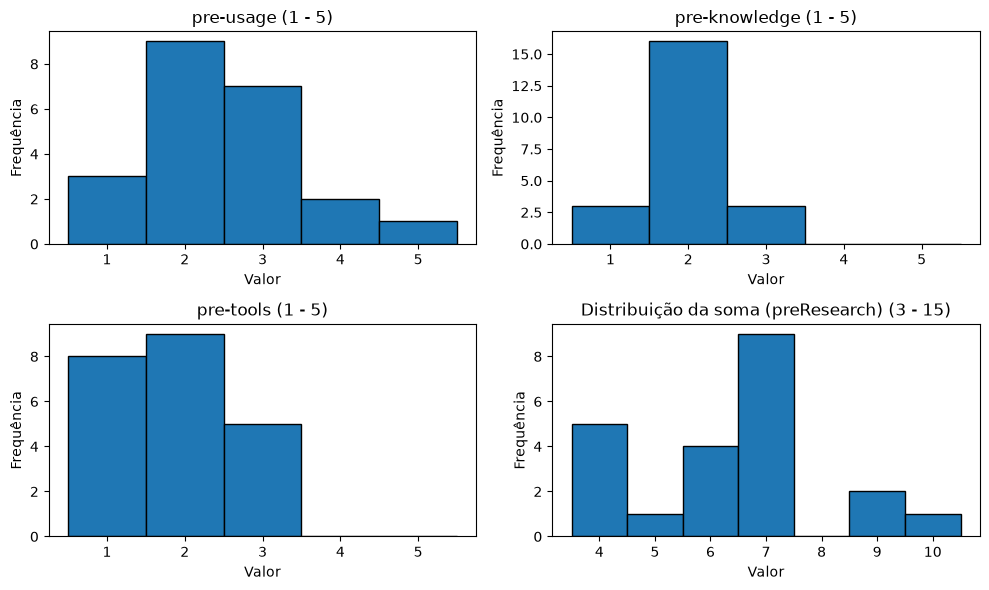

In [7]:
question_ids = [item.get("questionId") for item in data[0].get("preResearch", [])]

values_by_question = {qid: [] for qid in question_ids}
sums = []

for user in data:
    pre_research = user.get("preResearch", [])
    for item in pre_research:
        qid = item.get("questionId")
        answer = item.get("answer", 0)
        if qid in values_by_question and str(answer).isdigit():
            values_by_question[qid].append(int(answer))
    sums.append(user.get("preResearchSum", 0))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for ax, qid in zip(axes[:3], question_ids):
    ax.hist(values_by_question[qid], bins=range(1, 7), edgecolor="black", align="left")
    ax.set_title(qid + " (1 - 5)")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")
    ax.set_xticks([1, 2, 3, 4, 5])

axes[3].cla()
axes[3].hist(sums, bins=range(min(sums), max(sums) + 2), edgecolor="black", align="left")
axes[3].set_title("Distribuição da soma (preResearch) (3 - 15)")
axes[3].set_xlabel("Valor")
axes[3].set_ylabel("Frequência")
axes[3].set_xticks(range(min(sums), max(sums) + 1))

plt.tight_layout()
plt.show()

In [8]:
def descriptive_stats(values):
    s = pd.Series(values, dtype="float")
    modes = s.mode().tolist()
    return {
        "n": int(s.count()),
        "média": s.mean(),
        "mediana": s.median(),
        "desvio_padrão": s.std(ddof=1),
        "mín": s.min(),
        "máx": s.max(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
        "moda": modes[0] if modes else None,
    }

stats = {qid: descriptive_stats(values) for qid, values in values_by_question.items()}
stats["preResearchSum"] = descriptive_stats(sums)

stats_df = pd.DataFrame(stats).T

print("Análise estatística das respostas do preResearch:")
print(stats_df.round(2))

Análise estatística das respostas do preResearch:
                   n  média  mediana  desvio_padrão  mín   máx   iqr  moda
pre-usage       22.0   2.50      2.0           1.01  1.0   5.0  1.00   2.0
pre-knowledge   22.0   2.00      2.0           0.53  1.0   3.0  0.00   2.0
pre-tools       22.0   1.86      2.0           0.77  1.0   3.0  1.00   2.0
preResearchSum  22.0   6.36      7.0           1.71  4.0  10.0  1.75   7.0


## Correlação entre as respostas e a idade e o tempo de experiência

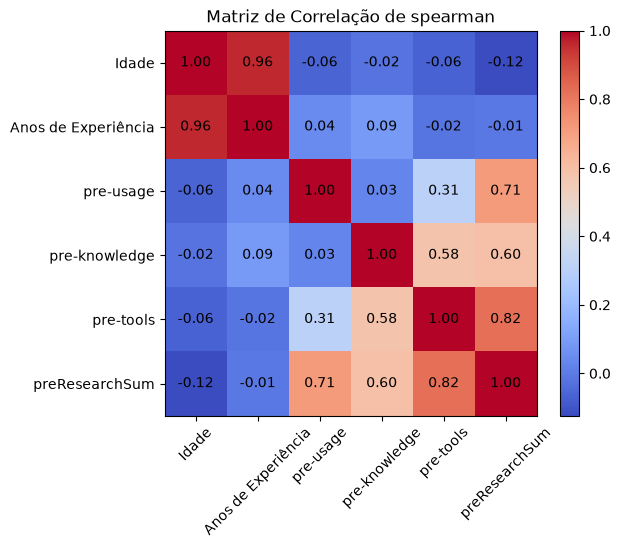

In [9]:
current_year = datetime.now().year
ages = [current_year - datetime.strptime(user['birthDate'], '%Y-%m-%d').year for user in data]
experience_years = [user['yearsOfPractice'] for user in data]

pre_usage = [int(user['preResearch'][0]['answer']) for user in data]
pre_knowledge = [int(user['preResearch'][1]['answer']) for user in data]
pre_tools = [int(user['preResearch'][2]['answer']) for user in data]
pre_research_sum = [user['preResearchSum'] for user in data]

correlation_data = {
    'Idade': ages,
    'Anos de Experiência': experience_years,
    'pre-usage': pre_usage,
    'pre-knowledge': pre_knowledge,
    'pre-tools': pre_tools,
    'preResearchSum': pre_research_sum
}
correlation_df = pd.DataFrame(correlation_data)

correlation_matrix = correlation_df.corr("spearman")

plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', color='black')
plt.title('Matriz de Correlação de spearman')
plt.show()

A frequência de utilização de sistemas baseados em IA não tem correlação com o nível de conhecimento prévio sobre XAI (correlação de spearman = 0.03). Já o conhecimento prévio sobre XAI e a experiência com este tipo de ferramenta tem uma correlação positiva moderada (correlação de spearman = 0.58).

## Alpha de Cronbach para pre-usage, pre-knowledge e pre-tools

O questionário composto pelas três perguntas sobre conhecimento prévio tem um coeficiente alpha de Cronbach de 0.52, indicando uma consistência interna baixa, ou seja, não estão medindo o mesmo objeto e serão analisados separadamente. Por isso, a variável de soma de pré-conhecimento não pode ser utilizada.

In [10]:
import numpy as np

items = np.array([pre_usage, pre_knowledge, pre_tools]).T

item_variances = items.var(axis=0, ddof=1)
total_scores = items.sum(axis=1)
total_variance = total_scores.var(ddof=1)

k = items.shape[1]
alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

print(f"Número de itens (k): {k}")
print(f"Número de participantes (n): {items.shape[0]}")
print(f"Variâncias por item: pre-usage={item_variances[0]:.4f}, pre-knowledge={item_variances[1]:.4f}, pre-tools={item_variances[2]:.4f}")
print(f"Variância total: {total_variance:.4f}")
print(f"\nAlpha de Cronbach: {alpha:.4f}")


Número de itens (k): 3
Número de participantes (n): 22
Variâncias por item: pre-usage=1.0238, pre-knowledge=0.2857, pre-tools=0.5996
Variância total: 2.9091

Alpha de Cronbach: 0.5156
